# 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

import librosa

import tensorflow as tf

import matplotlib.pyplot as plt

# 데이터 불러오기

In [2]:
df = pd.read_csv("./data/file_names.csv")
df.head()

,file_name,class,class_num
0,100648-1-0-0.wav,자동차 경적,8
1,100648-1-1-0.wav,자동차 경적,8
2,100648-1-2-0.wav,자동차 경적,8
3,100648-1-3-0.wav,자동차 경적,8
4,100648-1-4-0.wav,자동차 경적,8


class    
개 짖는 소리       1000    
자동차 경적         563    
화재 경보          186    
도난 경보          130    
응급 경보           67    
침입 경보           21    
경찰차 사이렌         18    
소방차 사이렌         13    
구급차 사이렌         11    
공습 경보           10    
가스누설 화재 경보       7    
Name: count, dtype: int64

In [3]:
# 데이터 분포 확인
df['class'].value_counts()

class
개 짖는 소리       1000
자동차 경적         559
화재 경보          186
도난 경보          130
응급 경보           67
침입 경보           21
경찰차 사이렌         18
소방차 사이렌         13
구급차 사이렌         11
공습 경보           10
가스누설 화재 경보       7
Name: count, dtype: int64

### `max_len` 설정하기    
$frames = [\frac{원본 샘플 수 - n\_fft}{hop\_length}]+1$

In [4]:
# sr = 16000
# n_fft = 1024
# hop_length = 256

# frame_lengths = []
# too_short = []

# for root, dirs, files in os.walk("./data/Train"):
#     for fname in files:
#         path = os.path.join(root, fname)
        
#         # Load audio
#         y, _ = librosa.load(path, sr=sr)
        
#         num_samples = len(y)

#         # 너무 짧으면 스킵
#         if num_samples <= n_fft:
#             too_short.append((fname, num_samples))
#             continue
        
#         # 프레임 수 계산
#         frames = 1 + (num_samples - n_fft) // hop_length
#         frame_lengths.append(frames)

# # numpy array 변환
# frame_lengths = np.array(frame_lengths)

# print("총 파일 수:", len(frame_lengths))
# print("최소:", frame_lengths.min())
# print("최대:", frame_lengths.max())
# print("평균:", frame_lengths.mean())
# print("중앙값:", np.median(frame_lengths))

# print("50th percentile:", np.percentile(frame_lengths, 50))
# print("75th percentile:", np.percentile(frame_lengths, 75))
# print("90th percentile:", np.percentile(frame_lengths, 90))
# print("95th percentile:", np.percentile(frame_lengths, 95))
# print("99th percentile:", np.percentile(frame_lengths, 99))

총 파일 수: 2022    
최소: 1    
최대: 3728    
평균: 454.5657764589515    
중앙값: 247.0    
50th percentile: 247.0    
75th percentile: 672.75    
90th percentile: 1117.7000000000012    
95th percentile: 1748.0    
99th percentile: 1921.0    

In [5]:
# too_short

[('17307-1-0-0.wav', 960),    
 ('87275-1-1-0.wav', 800),    
 ('87275-1-2-0.wav', 800),    
 ('87275-1-3-0.wav', 960)]

In [6]:
# df[df['file_name'].isin([f for f, _ in too_short])]

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>file_name</th>
      <th>class</th>
      <th>class_num</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>80</th>
      <td>17307-1-0-0.wav</td>
      <td>자동차 경적</td>
      <td>8</td>
    </tr>
    <tr>
      <th>406</th>
      <td>87275-1-1-0.wav</td>
      <td>자동차 경적</td>
      <td>8</td>
    </tr>
    <tr>
      <th>407</th>
      <td>87275-1-2-0.wav</td>
      <td>자동차 경적</td>
      <td>8</td>
    </tr>
    <tr>
      <th>408</th>
      <td>87275-1-3-0.wav</td>
      <td>자동차 경적</td>
      <td>8</td>
    </tr>
  </tbody>
</table>
</div>

In [7]:
# # 길이가 너무 짧은 음성은 학습에 이용 X
# df = df[~df['file_name'].isin([f for f, _ in too_short])]
# print(df.shape)
# df['class'].value_counts() 

(2022, 3)    
    
class    
개 짖는 소리       1000    
자동차 경적         559    
화재 경보          186    
도난 경보          130    
응급 경보           67    
침입 경보           21    
경찰차 사이렌         18    
소방차 사이렌         13    
구급차 사이렌         11    
공습 경보           10    
가스누설 화재 경보       7    
Name: count, dtype: int64    

In [8]:
# 저장
# df.to_csv('./data/file_names.csv', index=False)

In [9]:
# plt.figure(figsize = (12, 2))
# plt.boxplot(frame_lengths, vert=False)
# plt.xticks(np.arange(0, 4000, 200))
# plt.show()


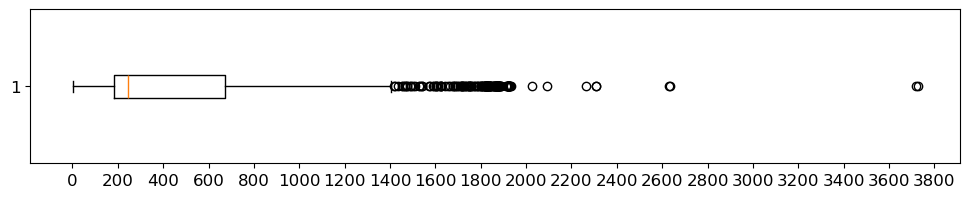

#### `max_len = 1024`
- 길이 분포를 봤더니 90%가 1117프레임 이하 → 이 정도만 커버해도 충분하다고 판단
- 1118 근처이면서 계산/모델에 편한 2의 제곱수인 1024프레임으로 스냅

In [10]:
max_len = 1024

## Dataset Split
Stratified Split => Train : Validation : Test = 6:2:2

### Train / Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(df['file_name'], df['class_num'], test_size=0.2, random_state=42, stratify=df['class_num'])
X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape

((1617,), (405,), (1617,), (405,))

In [13]:
y_test.value_counts()

class_num
1     200
8     112
10     37
5      26
7      14
2       4
9       4
6       3
3       2
4       2
0       1
Name: count, dtype: int64

### Train / Validation Split

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((1212,), (405,), (1212,), (405,))

In [15]:
y_train.value_counts()

class_num
1     600
8     335
10    112
5      78
7      40
9      13
2      10
4       7
6       7
3       6
0       4
Name: count, dtype: int64

In [16]:
y_valid.value_counts()

class_num
1     200
8     112
10     37
5      26
7      13
9       4
2       4
6       3
3       2
4       2
0       2
Name: count, dtype: int64

# 특징 추출 
## 함수 정의

In [17]:
def logmel_extraction(x, y, base_dir='./data/Train', sr=16000, n_fft=1024, hop_length=256, n_mels=64, max_len=1024):
    result_x = []
    result_y = []

    for fname, label in tqdm(zip(x, y), total=len(x), desc='Extracting Log-Mel'):
        # 실제 파일 경로 만들기
        path = os.path.join(base_dir, fname)

        # Load audio
        data_x, sampling_rate = librosa.load(path, sr=sr)

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=data_x,
            sr=sampling_rate,  # sampling rate
            n_fft=n_fft,       # fft window size
            hop_length=hop_length,  # fram간 이동 간격
            n_mels=n_mels,     # mel 필터 수
            fmin=50,           # 분석할 최소 주파수
            fmax=sampling_rate // 2  # 분석할 최대 주파수
        )

        # Log scaling (dB)
        logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
        
        # 길이 맞추기
        pad_val = logmel.min()
        if logmel.shape[1] < max_len:
            pad_width = max_len - logmel.shape[1]
            logmel = np.pad(logmel, ((0, 0), (0, pad_width)), 'constant', constant_values=pad_val)
        else:
            logmel = logmel[:, :max_len]

        result_x.append(logmel[:, :, np.newaxis])    # CNN 입력 형태로
        result_y.append(label)

    return np.array(result_x), np.array(result_y)

In [18]:
def mfcc_extraction(x, y, base_dir='./data/Train', sr=16000, n_fft=1024, hop_length=256, n_mfcc=50, max_len=1024):
    result_x = []
    result_y = []

    for fname, label in tqdm(zip(x, y), total=len(x), desc='Extracting MFCC'):
        # 실제 파일 경로 만들기
        path = os.path.join(base_dir, fname)

        # Load audio
        data_x, sampling_rate = librosa.load(path, sr=sr)

        # MFCC 추출
        mfcc = librosa.feature.mfcc(
            y=data_x,
            sr=sampling_rate,
            n_mfcc=n_mfcc,      # 추출할 MFCC 수
            n_fft=n_fft,         # STFT 윈도우 크기
            hop_length=hop_length,
            norm='ortho', 
            fmin=50,           # 분석할 최소 주파수
            fmax=sampling_rate // 2  # 분석할 최대 주파수
        ).astype(np.float32)
        
        pad_val = mfcc.min()
        if mfcc.shape[1] < max_len:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), 'constant', constant_values=pad_val)
        else:
            mfcc = mfcc[:, :max_len]

        result_x.append(mfcc[ :, :, np.newaxis])
        result_y.append(label)

    return np.array(result_x), np.array(result_y)

## Train / Validation / Test Feature Extraction

In [19]:
# Log Mel 
X_train_logmel, y_train_logmel = logmel_extraction(X_train, y_train)
X_valid_logmel, y_valid_logmel = logmel_extraction(X_valid, y_valid)
X_test_logmel, y_test_logmel = logmel_extraction(X_test, y_test)

print()
print(X_train_logmel.shape, y_train_logmel.shape)
print(X_valid_logmel.shape, y_valid_logmel.shape)
print(X_test_logmel.shape, y_test_logmel.shape)

Extracting Log-Mel: 100%|██████████| 405/405 [00:26<00:00, 15.30it/s]


(1212, 64, 1024, 1) (1212,)
(405, 64, 1024, 1) (405,)
(405, 64, 1024, 1) (405,)


In [20]:
# MFCC
X_train_mfcc, y_train_mfcc = mfcc_extraction(X_train, y_train)
X_valid_mfcc, y_valid_mfcc = mfcc_extraction(X_valid, y_valid)
X_test_mfcc, y_test_mfcc = mfcc_extraction(X_test, y_test)

print()
print(X_train_mfcc.shape, y_train_mfcc.shape)
print(X_valid_mfcc.shape, y_valid_mfcc.shape)
print(X_test_mfcc.shape, y_test_mfcc.shape)

Extracting MFCC: 100%|██████████| 405/405 [00:19<00:00, 20.60it/s]


(1212, 50, 1024, 1) (1212,)
(405, 50, 1024, 1) (405,)
(405, 50, 1024, 1) (405,)


## 파일로 저장

In [21]:
os.makedirs('data/features', exist_ok=True)

np.savez('data/features/train_logmel.npz', X=X_train_logmel, y=y_train_logmel)
np.savez('data/features/valid_logmel.npz', X=X_valid_logmel, y=y_valid_logmel)
np.savez('data/features/test_logmel.npz', X=X_test_logmel, y=y_test_logmel)

np.savez('data/features/train_mfcc.npz', X=X_train_mfcc, y=y_train_mfcc)
np.savez('data/features/valid_mfcc.npz', X=X_valid_mfcc, y=y_valid_mfcc)
np.savez('data/features/test_mfcc.npz', X=X_test_mfcc, y=y_test_mfcc)

In [ ]:
# 불러오기 예시

# data = np.load('data/features/train_logmel.npz') 
# X_train, y_train = data['X'], data['y']